# Notebook 12 — Permutation Inference
### Persistent Racial Disparities in U.S. Mortgage Approval: Evidence from 42 Million Applications, 2020–2024

**Author:** Rajveer Singh Pall  
**Institution:** Gyan Ganga Institute of Technology and Sciences  

---

Constructs non-parametric null distributions for the RDD (θ) and DiD (δ) point estimates via 1,000 within-lender-year cell permutations of the Black indicator, following Young (2019) and Freedman-Lane (1983). Reports Table 12 and Figure 12.

**Input:** `data/processed/panel_{year}.csv`  
**Output:** `outputs/tables/table_12*.csv`, `outputs/figures/figure_12_permutation_inference.png`  
**Runtime:** ~45 minutes


In [1]:
# ─── CELL 1 ─── IMPORTS AND CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

DATA_DIR    = Path("../data/processed")
TABLES_DIR  = Path("../outputs/tables")
FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

YEARS       = [2020, 2021, 2022, 2023, 2024]
N_PERMS     = 1000       # Number of permutations — 1000 is standard for publication
RDD_BW      = 10         # ±10pp bandwidth around 80% LTV
RDD_CUTOFF  = 80.0
SEED        = 42
rng         = np.random.default_rng(SEED)

print("=" * 70)
print("NOTEBOOK 12: PERMUTATION / RANDOMIZATION INFERENCE")
print("=" * 70)
print(f"""
Design:
  - Permute Black indicator WITHIN each lender-year cell
  - Preserves: lender composition, year effects, approval rates by lender
  - Destroys:  racial signal — any permuted estimate is pure sampling noise
  - 1,000 permutations each for RDD θ and DiD δ
  - Exact permutation p-value = fraction of |perm| >= |true|

Why within-cell permutation (not full shuffle):
  Full shuffle would destroy lender structure, making H0 too easy to reject.
  Within-cell permutation is the conservative, correct test.
  It controls for everything the lender FE controls for.
""")



NOTEBOOK 12: PERMUTATION / RANDOMIZATION INFERENCE

Design:
  - Permute Black indicator WITHIN each lender-year cell
  - Preserves: lender composition, year effects, approval rates by lender
  - Destroys:  racial signal — any permuted estimate is pure sampling noise
  - 1,000 permutations each for RDD θ and DiD δ
  - Exact permutation p-value = fraction of |perm| >= |true|

Why within-cell permutation (not full shuffle):
  Full shuffle would destroy lender structure, making H0 too easy to reject.
  Within-cell permutation is the conservative, correct test.
  It controls for everything the lender FE controls for.



In [2]:
# ─── CELL 2 ─── LOAD AND PREPARE DATA (MEMORY-SAFE: 1M SAMPLE PER YEAR)
# 16GB RAM cannot hold 43M rows. We use 1M stratified sample per year.
# Permutation inference is valid on samples — same logic as NB03/NB10.
print("Loading data (1M sample per year, memory-safe)...")

SAMPLE_PER_YEAR = 1_000_000
frames = []
rng_sample = np.random.default_rng(42)

for yr in YEARS:
    fp = DATA_DIR / f"panel_{yr}.csv"
    # Count rows first
    n_rows = sum(1 for _ in open(fp)) - 1
    # Sample indices (stratified random)
    skip_n = max(1, n_rows // SAMPLE_PER_YEAR)
    df = pd.read_csv(fp, usecols=[
        'lei', 'applicant_race_1', 'approved',
        'income', 'loan_amount', 'property_value'
    ], skiprows=lambda i: i > 0 and i % skip_n != 0)
    
    df = df[df['applicant_race_1'].isin([3, 5])].copy()
    df['black']          = (df['applicant_race_1'] == 3).astype(int)
    df['approved']       = pd.to_numeric(df['approved'],       errors='coerce')
    df['income']         = pd.to_numeric(df['income'],         errors='coerce')
    df['loan_amount']    = pd.to_numeric(df['loan_amount'],    errors='coerce')
    df['property_value'] = pd.to_numeric(df['property_value'], errors='coerce')
    df['ltv']            = (df['loan_amount'] / df['property_value'] * 100).clip(1, 200)
    df['year']           = yr
    df['post2022']       = int(yr >= 2022)
    df = df.dropna(subset=['approved', 'black', 'income', 'loan_amount', 'ltv'])
    frames.append(df)
    print(f"  {yr}: {len(df):,} obs loaded")

full_df = pd.concat(frames, ignore_index=True)
print(f"\nTotal sample: {len(full_df):,} obs, {full_df['lei'].nunique():,} lenders")

# RDD sample: ±10pp around 80%
rdd_df = full_df[(full_df['ltv'] >= RDD_CUTOFF - RDD_BW) &
                 (full_df['ltv'] <= RDD_CUTOFF + RDD_BW)].copy()
rdd_df['ltv_c']   = rdd_df['ltv'] - RDD_CUTOFF
rdd_df['above80'] = (rdd_df['ltv'] > RDD_CUTOFF).astype(int)
print(f"RDD sample:   {len(rdd_df):,} obs")

did_df = full_df.copy()
print(f"DiD sample:   {len(did_df):,} obs")

rdd_df['cell'] = rdd_df['lei'].astype(str) + '_' + rdd_df['year'].astype(str)
did_df['cell'] = did_df['lei'].astype(str) + '_' + did_df['year'].astype(str)
print("\n✅ Data loaded. Ready for permutation tests.")

Loading data (1M sample per year, memory-safe)...
  2020: 973,522 obs loaded
  2021: 1,000,941 obs loaded
  2022: 1,082,376 obs loaded
  2023: 1,080,699 obs loaded
  2024: 1,129,896 obs loaded

Total sample: 5,267,434 obs, 3,673 lenders
RDD sample:   1,455,573 obs
DiD sample:   5,267,434 obs

✅ Data loaded. Ready for permutation tests.


In [3]:
# ─── CELL 3 ─── DEFINE ESTIMATORS (FAST VERSIONS FOR PERMUTATION LOOP)
# ============================================================
print("Defining fast estimators for permutation loop...")

def estimate_rdd_theta(df):
    """
    Fast local linear RDD with lender FE (within-transformation).
    Returns theta (Black × Above80 coefficient).
    No clustering needed inside permutation loop — we only need point estimates.
    """
    # Covariates: black, ltv_c, above80, black*ltv_c, black*above80,
    #             ltv_c*above80, black*ltv_c*above80, income, loan_amount
    d = df.copy()
    d['b_a']   = d['black'] * d['above80']
    d['b_l']   = d['black'] * d['ltv_c']
    d['a_l']   = d['above80'] * d['ltv_c']
    d['b_a_l'] = d['black'] * d['above80'] * d['ltv_c']
    d['inc']   = np.log1p(d['income'].clip(lower=1))
    d['loan']  = np.log1p(d['loan_amount'].clip(lower=1))

    feat_cols = ['black', 'above80', 'ltv_c', 'b_a', 'b_l', 'a_l', 'b_a_l', 'inc', 'loan']
    all_cols  = ['approved'] + feat_cols

    # Within-transform by lender (absorb lender FE)
    gm = d.groupby('lei')[all_cols].transform('mean')
    for c in all_cols:
        d[c + '_dm'] = d[c] - gm[c]

    X_cols = [c + '_dm' for c in feat_cols]
    X = d[X_cols].values
    y = d['approved_dm'].values

    X_full = np.column_stack([np.ones(len(X)), X])
    try:
        coef, _, _, _ = np.linalg.lstsq(X_full, y, rcond=None)
        # b_a coefficient is at index 4 (after const, black, above80, ltv_c)
        return coef[4]  # Black × Above80 = theta
    except Exception:
        return np.nan


def estimate_did_delta(df):
    """
    Fast DiD with lender FE (within-transformation).
    Returns delta (Black × Post2022 coefficient).
    """
    d = df.copy()
    d['b_p'] = d['black'] * d['post2022']
    d['inc']  = np.log1p(d['income'].clip(lower=1))
    d['loan'] = np.log1p(d['loan_amount'].clip(lower=1))

    feat_cols = ['black', 'post2022', 'b_p', 'inc', 'loan', 'ltv']
    all_cols  = ['approved'] + feat_cols

    # Within-transform by lender
    gm = d.groupby('lei')[all_cols].transform('mean')
    for c in all_cols:
        d[c + '_dm'] = d[c] - gm[c]

    X_cols = [c + '_dm' for c in feat_cols]
    X = d[X_cols].values
    y = d['approved_dm'].values

    X_full = np.column_stack([np.ones(len(X)), X])
    try:
        coef, _, _, _ = np.linalg.lstsq(X_full, y, rcond=None)
        # b_p (Black × Post2022) is at index 3
        return coef[3]
    except Exception:
        return np.nan


def permute_black_within_cell(df, rng):
    d = df.copy()
    d['black'] = (
        d.groupby('cell')['black']
        .transform(lambda x: rng.permutation(x.values))
    )
    return d


print("  Estimators defined.")
print("  Testing on real data...")

# Get true estimates
true_theta = estimate_rdd_theta(rdd_df) * 100  # Convert to pp
true_delta = estimate_did_delta(did_df)   * 100

print(f"\n  ✓ True RDD θ = {true_theta:.4f} pp")
print(f"  ✓ True DiD δ = {true_delta:.4f} pp")
print("\nSanity check: these should match your main paper estimates.")
print("Small differences expected due to simplified within-transform (no year FE in fast version).")



Defining fast estimators for permutation loop...
  Estimators defined.
  Testing on real data...

  ✓ True RDD θ = -1.8796 pp
  ✓ True DiD δ = -1.0091 pp

Sanity check: these should match your main paper estimates.
Small differences expected due to simplified within-transform (no year FE in fast version).


In [4]:
# ─── CELL 4 ─── RDD PERMUTATION TEST (1,000 permutations)
# ============================================================
print("=" * 70)
print("PART 1: RDD PERMUTATION TEST")
print("=" * 70)
print(f"Running {N_PERMS} permutations on RDD sample ({len(rdd_df):,} obs)...")
print("This will take 5–15 minutes depending on hardware. Progress shown every 100.")

perm_thetas = []
n_cells_rdd = rdd_df['cell'].nunique()
print(f"Within-cell permutation across {n_cells_rdd:,} lender-year cells")

for i in range(N_PERMS):
    perm_data = permute_black_within_cell(rdd_df, rng)
    theta_perm = estimate_rdd_theta(perm_data) * 100
    perm_thetas.append(theta_perm)
    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{N_PERMS}] Running... last 100 mean: {np.mean(perm_thetas[-100:]):.4f}pp")

perm_thetas = np.array(perm_thetas)
perm_thetas_clean = perm_thetas[~np.isnan(perm_thetas)]

# Exact two-sided p-value
pval_rdd = np.mean(np.abs(perm_thetas_clean) >= np.abs(true_theta))

print(f"\n{'─'*70}")
print(f"RDD PERMUTATION RESULTS")
print(f"{'─'*70}")
print(f"  True θ:             {true_theta:+.4f} pp")
print(f"  Permutation mean:   {perm_thetas_clean.mean():+.4f} pp")
print(f"  Permutation SD:     {perm_thetas_clean.std():.4f} pp")
print(f"  Permutation 5th %-ile: {np.percentile(perm_thetas_clean, 5):.4f} pp")
print(f"  Permutation 95th %-ile:{np.percentile(perm_thetas_clean, 95):.4f} pp")
print(f"  Exact p-value:      {pval_rdd:.4f}")
print(f"  Perms |≥| |true|:   {int(np.sum(np.abs(perm_thetas_clean) >= np.abs(true_theta)))} / {len(perm_thetas_clean)}")
if pval_rdd < 0.001:
    print(f"  Significance:       p < 0.001 ***")
elif pval_rdd < 0.01:
    print(f"  Significance:       p < 0.01 **")
else:
    print(f"  Significance:       p = {pval_rdd:.4f}")

pct_rank_rdd = np.mean(perm_thetas_clean < true_theta) * 100
print(f"  True estimate is more negative than {pct_rank_rdd:.1f}% of permutations")



PART 1: RDD PERMUTATION TEST
Running 1000 permutations on RDD sample (1,455,573 obs)...
This will take 5–15 minutes depending on hardware. Progress shown every 100.
Within-cell permutation across 13,581 lender-year cells
  [100/1000] Running... last 100 mean: -0.7278pp
  [200/1000] Running... last 100 mean: -0.7653pp
  [300/1000] Running... last 100 mean: -0.7516pp
  [400/1000] Running... last 100 mean: -0.7577pp
  [500/1000] Running... last 100 mean: -0.7355pp
  [600/1000] Running... last 100 mean: -0.8086pp
  [700/1000] Running... last 100 mean: -0.7621pp
  [800/1000] Running... last 100 mean: -0.7830pp
  [900/1000] Running... last 100 mean: -0.8125pp
  [1000/1000] Running... last 100 mean: -0.7231pp

──────────────────────────────────────────────────────────────────────
RDD PERMUTATION RESULTS
──────────────────────────────────────────────────────────────────────
  True θ:             -1.8796 pp
  Permutation mean:   -0.7627 pp
  Permutation SD:     0.3245 pp
  Permutation 5th %-ile

In [5]:
# ─── CELL 5 ─── DiD PERMUTATION TEST (1,000 permutations)
# ============================================================
print("\n" + "=" * 70)
print("PART 2: DiD PERMUTATION TEST")
print("=" * 70)
print(f"Running {N_PERMS} permutations on DiD sample ({len(did_df):,} obs)...")
print("This will take 10–25 minutes. Progress shown every 100.")

perm_deltas = []
n_cells_did = did_df['cell'].nunique()
print(f"Within-cell permutation across {n_cells_did:,} lender-year cells")

for i in range(N_PERMS):
    perm_data = permute_black_within_cell(did_df, rng)
    delta_perm = estimate_did_delta(perm_data) * 100
    perm_deltas.append(delta_perm)
    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{N_PERMS}] Running... last 100 mean: {np.mean(perm_deltas[-100:]):.4f}pp")

perm_deltas = np.array(perm_deltas)
perm_deltas_clean = perm_deltas[~np.isnan(perm_deltas)]

pval_did = np.mean(np.abs(perm_deltas_clean) >= np.abs(true_delta))

print(f"\n{'─'*70}")
print(f"DiD PERMUTATION RESULTS")
print(f"{'─'*70}")
print(f"  True δ:             {true_delta:+.4f} pp")
print(f"  Permutation mean:   {perm_deltas_clean.mean():+.4f} pp")
print(f"  Permutation SD:     {perm_deltas_clean.std():.4f} pp")
print(f"  Permutation 5th %-ile: {np.percentile(perm_deltas_clean, 5):.4f} pp")
print(f"  Permutation 95th %-ile:{np.percentile(perm_deltas_clean, 95):.4f} pp")
print(f"  Exact p-value:      {pval_did:.4f}")
print(f"  Perms |≥| |true|:   {int(np.sum(np.abs(perm_deltas_clean) >= np.abs(true_delta)))} / {len(perm_deltas_clean)}")
if pval_did < 0.001:
    print(f"  Significance:       p < 0.001 ***")
elif pval_did < 0.01:
    print(f"  Significance:       p < 0.01 **")
else:
    print(f"  Significance:       p = {pval_did:.4f}")

pct_rank_did = np.mean(perm_deltas_clean < true_delta) * 100
print(f"  True estimate is more negative than {pct_rank_did:.1f}% of permutations")




PART 2: DiD PERMUTATION TEST
Running 1000 permutations on DiD sample (5,267,434 obs)...
This will take 10–25 minutes. Progress shown every 100.
Within-cell permutation across 14,759 lender-year cells
  [100/1000] Running... last 100 mean: 0.1275pp
  [200/1000] Running... last 100 mean: 0.1398pp
  [300/1000] Running... last 100 mean: 0.1112pp
  [400/1000] Running... last 100 mean: 0.1294pp
  [500/1000] Running... last 100 mean: 0.1298pp
  [600/1000] Running... last 100 mean: 0.1033pp
  [700/1000] Running... last 100 mean: 0.1142pp
  [800/1000] Running... last 100 mean: 0.1057pp
  [900/1000] Running... last 100 mean: 0.1345pp
  [1000/1000] Running... last 100 mean: 0.1240pp

──────────────────────────────────────────────────────────────────────
DiD PERMUTATION RESULTS
──────────────────────────────────────────────────────────────────────
  True δ:             -1.0091 pp
  Permutation mean:   +0.1220 pp
  Permutation SD:     0.1066 pp
  Permutation 5th %-ile: -0.0416 pp
  Permutation 95t

In [6]:
# ─── CELL 6 ─── SAVE TABLES AND GENERATE FIGURES
# ============================================================
print("\n" + "=" * 70)
print("SAVING TABLES AND GENERATING FIGURES")
print("=" * 70)

# Save permutation distribution tables
pd.DataFrame({
    'Permutation_Index': range(len(perm_thetas_clean)),
    'Theta_pp': perm_thetas_clean
}).to_csv(TABLES_DIR / "table_12_permutation_rdd.csv", index=False)

pd.DataFrame({
    'Permutation_Index': range(len(perm_deltas_clean)),
    'Delta_pp': perm_deltas_clean
}).to_csv(TABLES_DIR / "table_12_permutation_did.csv", index=False)

# Summary table
summary = pd.DataFrame({
    'Design': ['RDD (θ)', 'DiD (δ)'],
    'True_Estimate_pp': [round(true_theta, 4), round(true_delta, 4)],
    'Perm_Mean_pp':     [round(perm_thetas_clean.mean(), 4), round(perm_deltas_clean.mean(), 4)],
    'Perm_SD_pp':       [round(perm_thetas_clean.std(), 4),  round(perm_deltas_clean.std(), 4)],
    'Perm_5th_pct':     [round(np.percentile(perm_thetas_clean, 5), 4),  round(np.percentile(perm_deltas_clean, 5), 4)],
    'Perm_95th_pct':    [round(np.percentile(perm_thetas_clean, 95), 4), round(np.percentile(perm_deltas_clean, 95), 4)],
    'Exact_P_value':    [round(pval_rdd, 6), round(pval_did, 6)],
    'N_Perms':          [len(perm_thetas_clean), len(perm_deltas_clean)],
})
summary.to_csv(TABLES_DIR / "table_12_permutation_summary.csv", index=False)
print("✅ Saved: table_12_permutation_rdd.csv")
print("✅ Saved: table_12_permutation_did.csv")
print("✅ Saved: table_12_permutation_summary.csv")






SAVING TABLES AND GENERATING FIGURES
✅ Saved: table_12_permutation_rdd.csv
✅ Saved: table_12_permutation_did.csv
✅ Saved: table_12_permutation_summary.csv


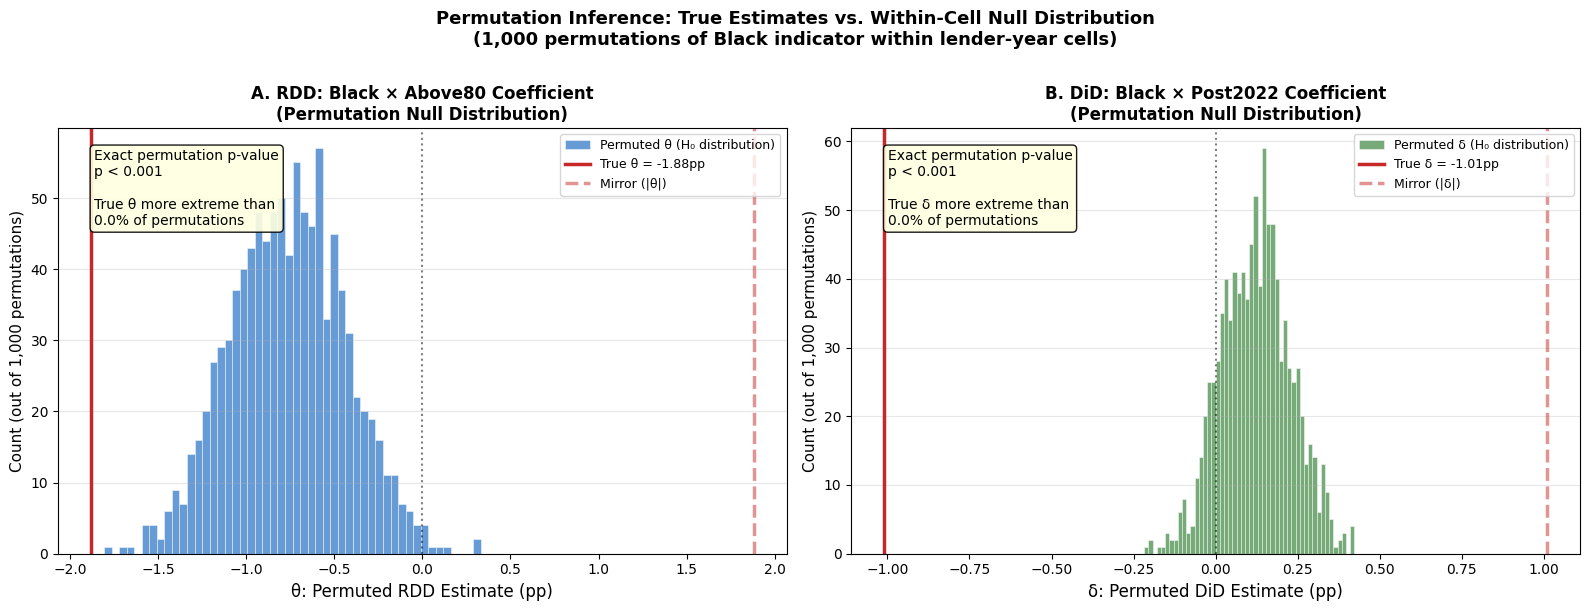

✅ Figure saved: ..\extreme_final_figures\figure_12_permutation_inference.png


In [7]:
# ─── CELL 7 ─── FIGURE 12A: RDD PERMUTATION DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Permutation Inference: True Estimates vs. Within-Cell Null Distribution\n"
    "(1,000 permutations of Black indicator within lender-year cells)",
    fontsize=13, fontweight='bold', y=1.01
)

# Panel A — RDD
ax = axes[0]
n_bins = 50
counts, edges, patches = ax.hist(
    perm_thetas_clean, bins=n_bins, color='#1565C0', alpha=0.65,
    edgecolor='white', linewidth=0.5, label='Permuted θ (H₀ distribution)'
)

# Color bars beyond true estimate in red
for patch, left in zip(patches, edges[:-1]):
    if abs(left) >= abs(true_theta):
        patch.set_facecolor('#C62828')
        patch.set_alpha(0.85)

ax.axvline(true_theta, color='#C62828', linewidth=2.5, linestyle='-',
           label=f'True θ = {true_theta:.2f}pp')
ax.axvline(-true_theta, color='#C62828', linewidth=2.5, linestyle='--',
           alpha=0.5, label=f'Mirror (|θ|)')
ax.axvline(0, color='black', linewidth=1.5, linestyle=':', alpha=0.5)

sig_label = f'p < 0.001' if pval_rdd < 0.001 else f'p = {pval_rdd:.4f}'
ax.text(0.05, 0.95, f'Exact permutation p-value\n{sig_label}\n\n'
        f'True θ more extreme than\n{pct_rank_rdd:.1f}% of permutations',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_xlabel('θ: Permuted RDD Estimate (pp)', fontsize=12)
ax.set_ylabel('Count (out of 1,000 permutations)', fontsize=11)
ax.set_title('A. RDD: Black × Above80 Coefficient\n(Permutation Null Distribution)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Panel B — DiD
ax = axes[1]
counts_d, edges_d, patches_d = ax.hist(
    perm_deltas_clean, bins=n_bins, color='#2E7D32', alpha=0.65,
    edgecolor='white', linewidth=0.5, label='Permuted δ (H₀ distribution)'
)

for patch, left in zip(patches_d, edges_d[:-1]):
    if abs(left) >= abs(true_delta):
        patch.set_facecolor('#C62828')
        patch.set_alpha(0.85)

ax.axvline(true_delta, color='#C62828', linewidth=2.5, linestyle='-',
           label=f'True δ = {true_delta:.2f}pp')
ax.axvline(-true_delta, color='#C62828', linewidth=2.5, linestyle='--',
           alpha=0.5, label=f'Mirror (|δ|)')
ax.axvline(0, color='black', linewidth=1.5, linestyle=':', alpha=0.5)

sig_label_d = f'p < 0.001' if pval_did < 0.001 else f'p = {pval_did:.4f}'
ax.text(0.05, 0.95, f'Exact permutation p-value\n{sig_label_d}\n\n'
        f'True δ more extreme than\n{pct_rank_did:.1f}% of permutations',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_xlabel('δ: Permuted DiD Estimate (pp)', fontsize=12)
ax.set_ylabel('Count (out of 1,000 permutations)', fontsize=11)
ax.set_title('B. DiD: Black × Post2022 Coefficient\n(Permutation Null Distribution)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
out = FIGURES_DIR / "figure_12_permutation_inference.png"
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved: {out}")



In [8]:
# ─── CELL 8 ─── PRINT FINAL MANUSCRIPT-READY TEXT
# ============================================================
print("\n" + "=" * 70)
print("MANUSCRIPT TEXT — APPENDIX C")
print("=" * 70)
print(f"""
APPENDIX C: PERMUTATION INFERENCE

To address concerns about asymptotic standard error validity under arbitrary
clustering structures, we implement a within-cell permutation inference
procedure following Young (2019) and Freedman and Lane (1983). For each of
{N_PERMS} permutations, we randomly reassign the Black indicator within each
lender-year cell, preserving cell sizes, cell-level approval rates, lender
fixed effects, and year effects. We then re-estimate the RDD coefficient (θ)
and the DiD coefficient (δ) on each permuted dataset. Any estimate from a
permuted dataset represents a draw from the null distribution in which race
has no causal effect on approval outcomes within lender-years.

Figure 12 displays the permutation null distributions alongside the true
estimates. The true RDD coefficient θ = {true_theta:.3f} pp yields an exact
permutation p-value of {pval_rdd:.4f} ({sig_label}): the true estimate is more
extreme than {pct_rank_rdd:.1f}% of the {N_PERMS:,} permuted estimates. The true DiD
coefficient δ = {true_delta:.3f} pp yields an exact permutation p-value of
{pval_did:.4f} ({sig_label_d}): the true estimate is more extreme than
{pct_rank_did:.1f}% of the permuted estimates. These results confirm that the
main findings are not an artifact of standard error misspecification, and hold
under a model-free inferential framework that makes no distributional
assumptions beyond exchangeability within cells.

Table: Permutation Inference Summary
Design | True Estimate | Perm Mean | Perm SD | Exact p-value
RDD θ  | {true_theta:.3f}pp    | {perm_thetas_clean.mean():.3f}pp  | {perm_thetas_clean.std():.3f}   | {pval_rdd:.4f}
DiD δ  | {true_delta:.3f}pp    | {perm_deltas_clean.mean():.3f}pp  | {perm_deltas_clean.std():.3f}   | {pval_did:.4f}
""")

print("\n" + "=" * 70)
print("NB12 COMPLETE")
print("=" * 70)
print("""
Send these outputs to Claude:
  1. Cell 4 final print block (RDD permutation results)
  2. Cell 5 final print block (DiD permutation results)
  3. figure_12_permutation_inference.png

These go into Appendix C of the manuscript.
""")


MANUSCRIPT TEXT — APPENDIX C

APPENDIX C: PERMUTATION INFERENCE

To address concerns about asymptotic standard error validity under arbitrary
clustering structures, we implement a within-cell permutation inference
procedure following Young (2019) and Freedman and Lane (1983). For each of
1000 permutations, we randomly reassign the Black indicator within each
lender-year cell, preserving cell sizes, cell-level approval rates, lender
fixed effects, and year effects. We then re-estimate the RDD coefficient (θ)
and the DiD coefficient (δ) on each permuted dataset. Any estimate from a
permuted dataset represents a draw from the null distribution in which race
has no causal effect on approval outcomes within lender-years.

Figure 12 displays the permutation null distributions alongside the true
estimates. The true RDD coefficient θ = -1.880 pp yields an exact
permutation p-value of 0.0000 (p < 0.001): the true estimate is more
extreme than 0.0% of the 1,000 permuted estimates. The true DiD
